# **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "/content/Delhi_NCR_1990_2022_Safdarjung.csv"
df = pd.read_csv(file_path)
display(df)

,time,day,month,year,average temp,min temp,max temp,prcp
0,01-01-1990,Mon,Jan,1990,9.4,6.0,15.1,0.0
1,02-01-1990,Tue,Jan,1990,9.3,5.2,14.2,0.0
2,03-01-1990,Wed,Jan,1990,9.0,6.5,13.6,0.0
3,04-01-1990,Thu,Jan,1990,10.7,6.0,17.5,0.0
4,05-01-1990,Fri,Jan,1990,12.6,7.3,20.8,0.0
...,...,...,...,...,...,...,...,...
11889,21-07-2022,Thu,Jul,2022,28.6,26.8,30.6,21.2
11890,22-07-2022,Fri,Jul,2022,29.3,27.0,32.9,0.3
11891,23-07-2022,Sat,Jul,2022,30.1,25.5,34.9,8.9
11892,24-07-2022,Sun,Jul,2022,30.6,27.1,35.7,0.0


# **Cleaning and Handling the Dataset**

In [3]:
df['prcp'] = df['prcp'].replace(np.nan, 0)
display(df)

,time,day,month,year,average temp,min temp,max temp,prcp
0,01-01-1990,Mon,Jan,1990,9.4,6.0,15.1,0.0
1,02-01-1990,Tue,Jan,1990,9.3,5.2,14.2,0.0
2,03-01-1990,Wed,Jan,1990,9.0,6.5,13.6,0.0
3,04-01-1990,Thu,Jan,1990,10.7,6.0,17.5,0.0
4,05-01-1990,Fri,Jan,1990,12.6,7.3,20.8,0.0
...,...,...,...,...,...,...,...,...
11889,21-07-2022,Thu,Jul,2022,28.6,26.8,30.6,21.2
11890,22-07-2022,Fri,Jul,2022,29.3,27.0,32.9,0.3
11891,23-07-2022,Sat,Jul,2022,30.1,25.5,34.9,8.9
11892,24-07-2022,Sun,Jul,2022,30.6,27.1,35.7,0.0


In [4]:
df['average temp'] = df['average temp'].fillna(df['average temp'].mean())
df['min temp'] = df['min temp'].fillna(df['min temp'].mean())
df['max temp'] = df['max temp'].fillna(df['max temp'].mean())
display(df)

,time,day,month,year,average temp,min temp,max temp,prcp
0,01-01-1990,Mon,Jan,1990,9.4,6.0,15.1,0.0
1,02-01-1990,Tue,Jan,1990,9.3,5.2,14.2,0.0
2,03-01-1990,Wed,Jan,1990,9.0,6.5,13.6,0.0
3,04-01-1990,Thu,Jan,1990,10.7,6.0,17.5,0.0
4,05-01-1990,Fri,Jan,1990,12.6,7.3,20.8,0.0
...,...,...,...,...,...,...,...,...
11889,21-07-2022,Thu,Jul,2022,28.6,26.8,30.6,21.2
11890,22-07-2022,Fri,Jul,2022,29.3,27.0,32.9,0.3
11891,23-07-2022,Sat,Jul,2022,30.1,25.5,34.9,8.9
11892,24-07-2022,Sun,Jul,2022,30.6,27.1,35.7,0.0


In [5]:
df = df.drop(columns = 'time')
display(df)

,day,month,year,average temp,min temp,max temp,prcp
0,Mon,Jan,1990,9.4,6.0,15.1,0.0
1,Tue,Jan,1990,9.3,5.2,14.2,0.0
2,Wed,Jan,1990,9.0,6.5,13.6,0.0
3,Thu,Jan,1990,10.7,6.0,17.5,0.0
4,Fri,Jan,1990,12.6,7.3,20.8,0.0
...,...,...,...,...,...,...,...
11889,Thu,Jul,2022,28.6,26.8,30.6,21.2
11890,Fri,Jul,2022,29.3,27.0,32.9,0.3
11891,Sat,Jul,2022,30.1,25.5,34.9,8.9
11892,Sun,Jul,2022,30.6,27.1,35.7,0.0


# **Year-wise Grouping of Data (Mean)**

In [6]:
df_grouped_year = df.groupby('year').mean(['average temp', 'min temp', 'max temp', 'prcp'])
display(df_grouped_year)

,average temp,min temp,max temp,prcp
year,,,,
1990,24.766144,19.371169,31.358517,1.834521
1991,24.784295,19.158690,31.948348,1.676712
1992,24.205199,17.696598,30.905078,0.953552
1993,24.825186,18.510530,31.536889,2.177260
1994,24.697221,18.609311,31.254440,2.450959
1995,24.965744,18.822590,31.252039,2.257260
1996,24.320765,18.085426,31.083815,2.724590
1997,23.587123,17.980690,29.901515,1.268493
1998,24.534521,18.844772,31.056003,2.275616


# **Avg Temperature Variability (1990 - 2022)**

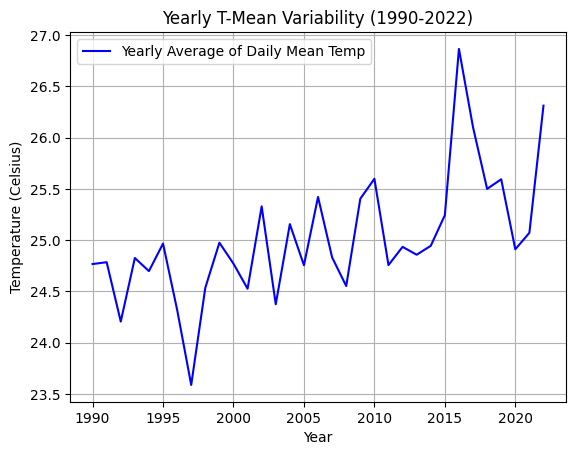

In [7]:
sns.lineplot(data = df_grouped_year, x = 'year', y = 'average temp', label = 'Yearly Average of Daily Mean Temp', color = 'blue')
plt.title('Yearly T-Mean Variability (1990-2022)')
plt.xlabel('Year')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.grid()
plt.show()


# **Max Temp Variability (1990-2022)**

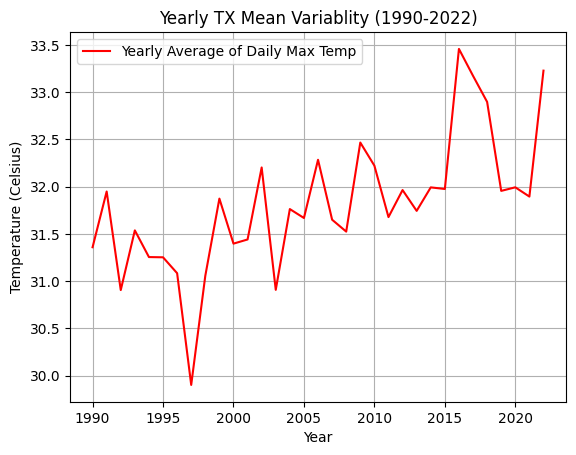

In [8]:
sns.lineplot(data = df_grouped_year, x = 'year', y = 'max temp', label = 'Yearly Average of Daily Max Temp', color = 'red')
plt.xlabel('Year')
plt.ylabel('Temperature (Celsius)')
plt.title('Yearly TX Mean Variablity (1990-2022)')
plt.legend()
plt.grid()
plt.show()

# **Min Temp Variabilty (1990-2022)**

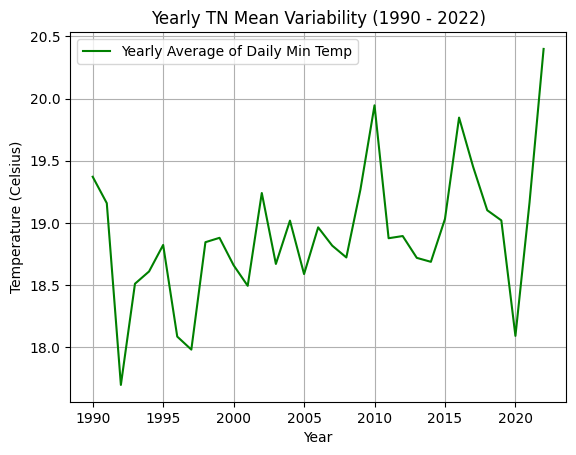

In [9]:
sns.lineplot(data = df_grouped_year, x = 'year', y = 'min temp', label = 'Yearly Average of Daily Min Temp', color = 'green')
plt.xlabel('Year')
plt.ylabel('Temperature (Celsius)')
plt.title('Yearly TN Mean Variability (1990 - 2022)')
plt.legend()
plt.grid()
plt.show()

# **Avg Daily Rainfall Variability**

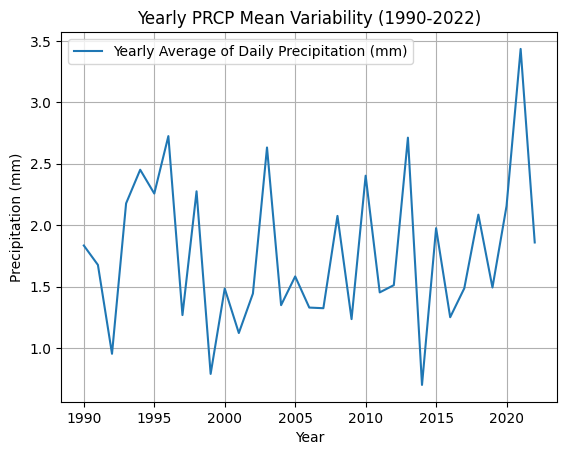

In [10]:
sns.lineplot(data = df_grouped_year, x = 'year', y = 'prcp', label = 'Yearly Average of Daily Precipitation (mm)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.title('Yearly PRCP Mean Variability (1990-2022)')
plt.legend()
plt.grid()
plt.show()

# **EDA - Pearson's Correlation**

In [11]:
df_correlation = df_grouped_year.corr(method = 'pearson')
display(df_correlation)

,average temp,min temp,max temp,prcp
average temp,1.000000,0.822547,0.939426,-0.095497
min temp,0.822547,1.000000,0.756052,0.041826
max temp,0.939426,0.756052,1.000000,-0.131317
prcp,-0.095497,0.041826,-0.131317,1.000000


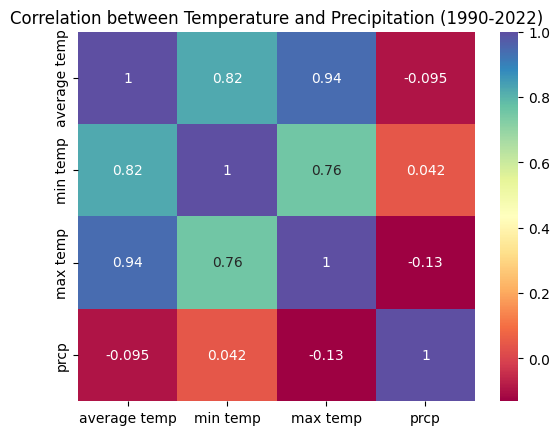

In [12]:
sns.heatmap(df_correlation, annot = True, cmap = 'Spectral')
plt.title('Correlation between Temperature and Precipitation (1990-2022)')
plt.show()

#**Seasonal Temperature Analysis**

**Summer Dataframe (Mar, Apr, May, Jun)**

In [13]:
df_summer_months = df[df['month'].isin(['Mar', 'Apr', 'May', 'Jun'])]
df_summer_grouped_year = df_summer_months.groupby('year').mean(['average temp', 'min temp', 'max temp', 'prcp'])
display(df_summer_grouped_year)

,average temp,min temp,max temp,prcp
year,,,,
1990,28.689344,21.626918,35.034474,0.734426
1991,28.902341,21.615227,35.648553,0.333607
1992,28.458341,20.001965,34.173817,1.345082
1993,29.000790,21.444047,35.596962,1.086066
1994,29.352400,21.652611,35.762054,2.144262
1995,29.782758,22.240600,36.233221,0.795082
1996,29.065574,21.464171,35.599228,1.122131
1997,27.474590,20.477186,34.084474,0.655738
1998,29.067213,21.420728,35.768467,1.390984


**Monsoon Dataframe (Jun, Jul, Aug, Sep)**

In [14]:
df_monsoon_months = df[df['month'].isin(['Jun', 'Jul', 'Aug', 'Sep'])]
df_monsoon_grouped_year = df_monsoon_months.groupby('year').mean(['average temp', 'min temp', 'max temp', 'prcp'])
display(df_monsoon_grouped_year)

,average temp,min temp,max temp,prcp
year,,,,
1990,30.446663,24.736102,35.029749,3.987705
1991,30.993384,24.718889,35.641851,4.633607
1992,29.151636,21.798150,34.119478,1.353279
1993,30.720492,24.915526,35.032112,6.075410
1994,30.341774,24.709069,34.693828,6.104098
1995,31.108197,25.230464,35.680762,5.605738
1996,29.862295,24.617350,34.281292,7.771311
1997,30.172951,24.359053,34.720829,2.244262
1998,30.672951,25.289665,35.034571,5.904918


**Winter Dataframe (Dec, Jan, Feb)**

In [15]:
df_winter_months = df[df['month'].isin(['Dec', 'Jan', 'Feb'])]
df_winter_grouped_year = df_winter_months.groupby('year').mean(['average temp', 'min temp', 'max temp', 'prcp'])
display(df_winter_grouped_year)

,average temp,min temp,max temp,prcp
year,,,,
1990,16.158650,12.664993,24.484313,1.491111
1991,15.418690,12.422386,25.036731,0.157778
1992,16.117267,11.912630,25.064059,0.081319
1993,15.743294,10.090591,23.956013,0.276667
1994,15.657778,11.125263,23.355033,0.390000
1995,15.017778,10.027258,22.107516,1.131111
1996,14.636264,8.984348,23.183969,0.315385
1997,13.692222,9.084537,21.409215,0.806667
1998,14.354444,10.099095,22.710327,0.148889


**Winter vs Summer Temperature Analysis**

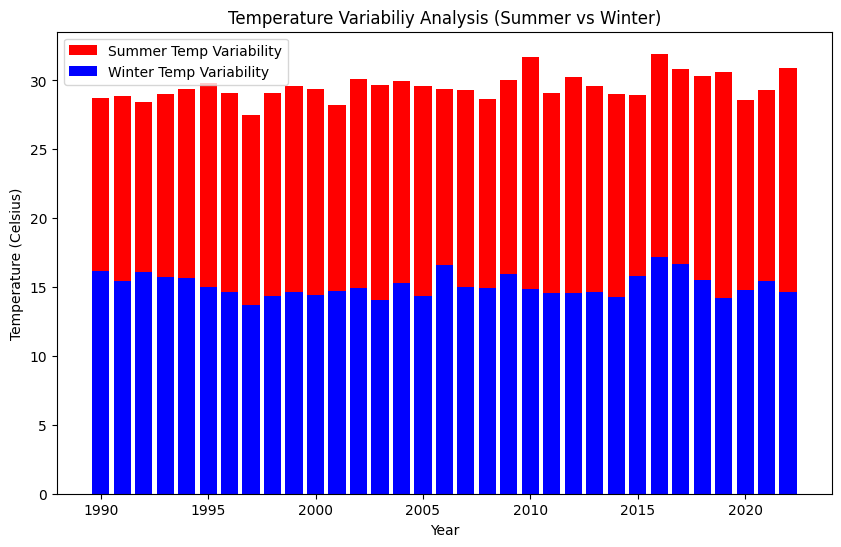

In [16]:
plt.figure(figsize =(10,6))
plt.bar(df_summer_grouped_year.index, df_summer_grouped_year['average temp'], label = 'Summer Temp Variability', color = 'red')
plt.bar(df_winter_grouped_year.index, df_winter_grouped_year['average temp'], label = 'Winter Temp Variability', color = 'blue')
plt.title('Temperature Variabiliy Analysis (Summer vs Winter)')
plt.xlabel('Year')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.show()

**Monsoon vs Winter Rainfall Variability Analysis**

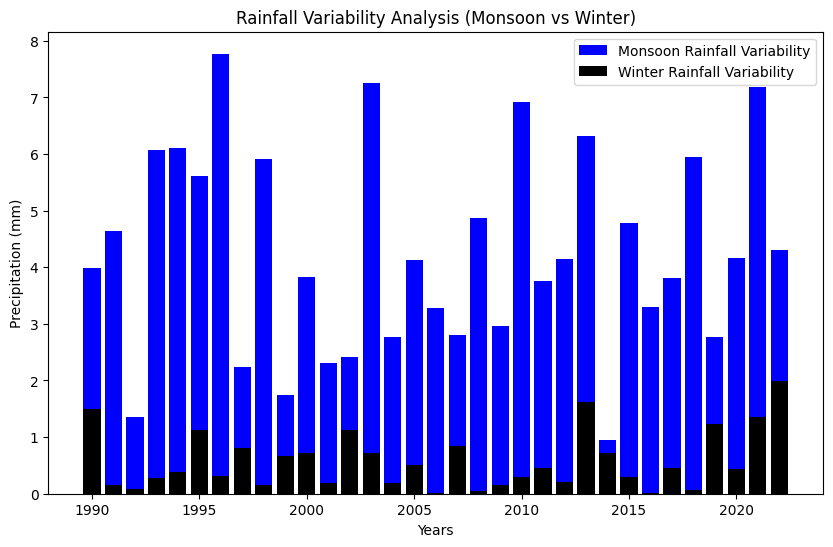

In [17]:
plt.figure(figsize =(10,6))
plt.bar(df_monsoon_grouped_year.index, df_monsoon_grouped_year['prcp'], label = 'Monsoon Rainfall Variability', color = 'blue')
plt.bar(df_winter_grouped_year.index, df_winter_grouped_year['prcp'],label = 'Winter Rainfall Variability', color = 'black')
plt.title('Rainfall Variability Analysis (Monsoon vs Winter)')
plt.xlabel('Years')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.show()

# **Regression Analysis of Temperature Trend**

**Annual trend of Daily Mean Temperature**

In [18]:
x = df_grouped_year.index.values.reshape(-1, 1)
averagetemp_y = df_grouped_year['average temp']

model = LR()
model.fit(x, averagetemp_y)

LinearRegression()

In [19]:
new_x = np.array([2025, 2030]).reshape(-1, 1)
predicted_avgtemp = model.predict(new_x)
print(predicted_avgtemp)

[25.76912369 25.96789514]


<function matplotlib.pyplot.show(close=None, block=None)>

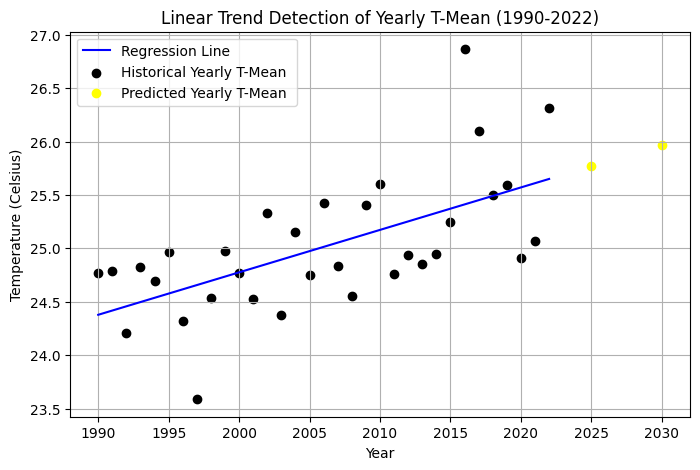

In [20]:
plt.figure(figsize = (8, 5))
plt.plot(x, model.predict(x), label = 'Regression Line', color = 'blue')
plt.scatter(x, averagetemp_y, label = 'Historical Yearly T-Mean', color = 'black')
plt.scatter(new_x, predicted_avgtemp, label = 'Predicted Yearly T-Mean ', color = 'yellow')
plt.title('Linear Trend Detection of Yearly T-Mean (1990-2022)')
plt.xlabel('Year')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.grid()
plt.show

In [21]:
R_square = r2_score(averagetemp_y, model.predict(x))
MAE = mean_absolute_error(averagetemp_y, model.predict(x))
MSE = mean_squared_error(averagetemp_y, model.predict(x))
RMSE = np.sqrt(MSE)
print("R^2 Score : ", R_square)
print("Mean Absolute Error : ", MAE)
print("Mean Squared Error : ", MSE)
print("Roor Mean Squared Error : ", RMSE)

R^2 Score :  0.3788483242237478
Mean Absolute Error :  0.39415296443051945
Mean Squared Error :  0.23493512268060182
Roor Mean Squared Error :  0.4847010652769414


**Annual Trend of Daily Maximum Temperature**

In [22]:
x = df_grouped_year.index.values.reshape(-1, 1)
maxtemp_y = df_grouped_year['max temp']
model = LR()
model.fit(x, maxtemp_y)

LinearRegression()

In [23]:
new_x = np.array([2025, 2030]).reshape(-1, 1)
predicted_maxtemp = model.predict(new_x)
print(predicted_maxtemp)

[32.74957255 32.99755352]


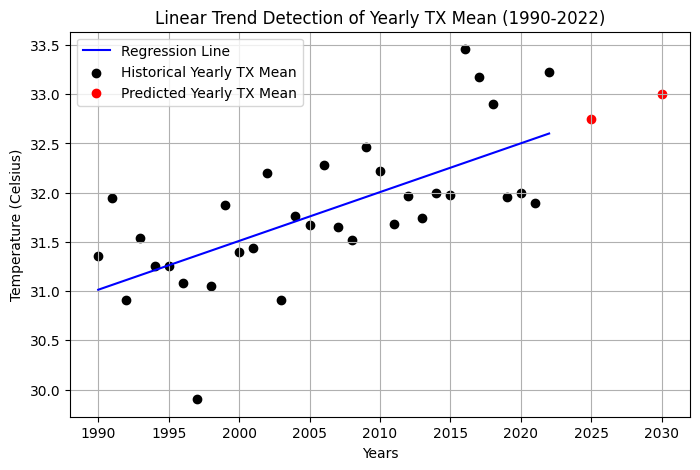

In [24]:
plt.figure(figsize = (8, 5))
plt.plot(x, model.predict(x), label = 'Regression Line', color = 'blue')
plt.scatter(x, maxtemp_y, label = 'Historical Yearly TX Mean', color = 'black')
plt.scatter(new_x, predicted_maxtemp, label = 'Predicted Yearly TX Mean', color = 'red')
plt.title('Linear Trend Detection of Yearly TX Mean (1990-2022)')
plt.xlabel('Years')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.grid()
plt.show()

In [25]:
R_square = r2_score(maxtemp_y, model.predict(x))
MAE = mean_absolute_error(maxtemp_y, model.predict(x))
MSE = mean_squared_error(maxtemp_y, model.predict(x))
RMSE = np.sqrt(MSE)
print("R^2 Score : ", R_square)
print("Mean Absolute Error : ", MAE)
print("Mean Squared Error : ", MSE)
print("Roor Mean Squared Error : ", RMSE)

R^2 Score :  0.442475245570471
Mean Absolute Error :  0.4244851164678119
Mean Squared Error :  0.2810085247060812
Roor Mean Squared Error :  0.5301023719113895


**Annual Trend of Daily Minimum Temperature**

In [26]:
x = df_grouped_year.index.values.reshape(-1, 1)
mintemp_y = df_grouped_year['min temp']
model = LR()
model.fit(x, mintemp_y)

LinearRegression()

In [27]:
new_x = np.array([2025, 2030]).reshape(-1, 1)
predicted_mintemp = model.predict(new_x)
print(predicted_mintemp)

[19.36610897 19.48934282]


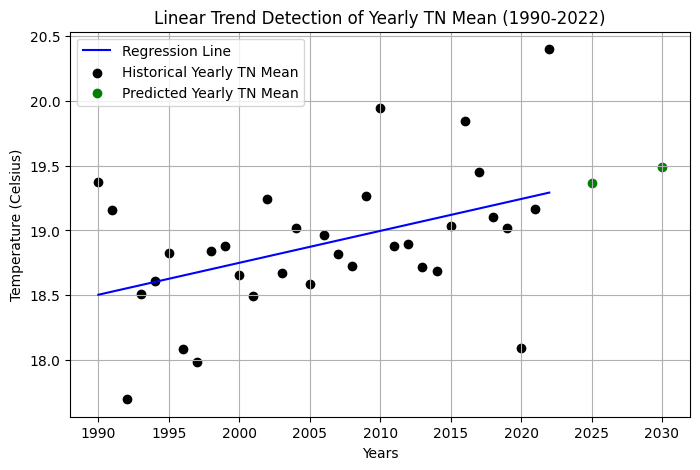

In [28]:
plt.figure(figsize = (8, 5))
plt.plot(x, model.predict(x), label = 'Regression Line', color = 'blue')
plt.scatter(x, mintemp_y, label = 'Historical Yearly TN Mean', color = 'black')
plt.scatter(new_x, predicted_mintemp, label = 'Predicted Yearly TN Mean', color = 'green')
plt.title('Linear Trend Detection of Yearly TN Mean (1990-2022)')
plt.xlabel('Years')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.grid()
plt.show()

In [29]:
R_square = r2_score(mintemp_y, model.predict(x))
MAE = mean_absolute_error(mintemp_y, model.predict(x))
MSE = mean_squared_error(mintemp_y, model.predict(x))
RMSE = np.sqrt(MSE)
print("R^2 Score : ", R_square)
print("Mean Absolute Error : ", MAE)
print("Mean Squared Error : ", MSE)
print("Roor Mean Squared Error : ", RMSE)

R^2 Score :  0.18952503180169344
Mean Absolute Error :  0.3645472774619462
Mean Squared Error :  0.23552699184827014
Roor Mean Squared Error :  0.4853112319411845


# **P-Value Calculations**

**Annual Trend of Daily Maximum Temperature**

In [30]:
x_max_temp = df_grouped_year.index.values
y_max_temp = df_grouped_year['max temp']
max_temp_slope, max_temp_intercept, max_temp_r_value, max_temp_p_value, max_temp_std_error = stats.linregress(x_max_temp, y_max_temp)

print("Slope of TX Mean Trend: ", max_temp_slope)
print("P-value of TX Mean Trend: ", format(max_temp_p_value, '.10f'))

Slope of TX Mean Trend:  0.049596192243936695
P-value of TX Mean Trend:  0.0000240768


**Annual Trend of Daily Minimum Temperature**

In [31]:
x_min_temp = df_grouped_year.index.values
y_min_temp = df_grouped_year['min temp']
min_temp_slope, min_temp_intercet, min_temp_r_value, min_temp_p_value, min_temp_std_error = stats.linregress(x_min_temp, y_min_temp)
print("Slope of TN Mean Trend: ", min_temp_slope)
print("P-value of TN Mean Trend: ", format(min_temp_p_value, '.10f'))

Slope of TN Mean Trend:  0.024646769530532926
P-value of TN Mean Trend:  0.0113363776


**Annual Trend of Daily Mean Temperature**

In [32]:
x_mean_temp = df_grouped_year.index.values
y_mean_temp = df_grouped_year['average temp']
mean_temp_slope, mean_temp_intercet, mean_temp_r_value, mean_temp_p_value, mean_temp_std_error = stats.linregress(x_mean_temp, y_mean_temp)
print("Slope of T-Mean Trend: ", mean_temp_slope)
print("P-value of T-Mean Trend: ", format(mean_temp_p_value, '.10f'))

Slope of T-Mean Trend:  0.03975429025045029
P-value of T-Mean Trend:  0.0001375901


**Annual Trend of Daily Precipitation**

In [33]:
x_prcp = df_grouped_year.index.values
y_prcp = df_grouped_year['prcp']
prcp_slope, prcp_intercet, prcp_r_value, prcp_p_value, prcp_std_error = stats.linregress(x_prcp, y_prcp)
print("Slope of Precipitation: ", prcp_slope)
print("P-value of Precipitation Trend: ", format(prcp_p_value, '.10f'))

Slope of Precipitation:  0.005672883640570738
P-value of Precipitation Trend:  0.6251365832
